In [128]:
!pip install torchtext sentencepiece
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm
!pip install datasets -q

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -------------------- ------------------- 6.6/12.8 MB 40.3 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 35.9 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 32.2 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
     ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
     ----------------------- ---------------- 8.7/14.6 MB 48.8 MB/s eta 0:00:01
     ------------------------------------- - 14.2/14.6 MB 35.5 MB/s eta 0:00:01
     ---------------------------------------- 14.6/14.6 MB 31.7 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


In [129]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter
import spacy

 Multi-Head Attention

In [130]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.dropout = nn.Dropout(p=0.1)

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.wo = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        # x: (batch, seq_len, d_model)
        # → (batch, n_heads, seq_len, d_k)
        x = x.view(batch_size, -1, self.n_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, x, context=None, mask=None):
        batch_size = x.size(0)
        kv = context if context is not None else x

        q = self.wq(x)
        k = self.wk(kv)
        v = self.wv(kv)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Scaled Dot-Product Attention
        # scores = QKᵀ / √dₖ
        scores = torch.matmul(q, k.transpose(-2,-1))/(self.d_k ** 0.5)

        # apply mask (causal or padding) before softmax
        if mask is not None:
          scores = scores.masked_fill(mask == 0, float('-inf'))

        # softmax over last axis → attention weights
        weights = F.softmax(scores, dim = -1)
        weights = self.dropout(weights)

        # weighted sum of values
        output = torch.matmul(weights, v)
        # end Scaled Dot-Product Attention

        output = output.transpose(1,2).contiguous().view(batch_size, -1, self.d_k * self.n_heads)
        output = self.wo(output)
        return output

In [131]:
# testing
mha = MultiHeadAttention(d_model=512, n_heads=8)
x = torch.randn(2, 6, 512)   # (batch=2, seq_len=6, d_model=512)
out, wt = mha.forward(x)
print(out.shape)  # torch.Size([2, 6, 512])

torch.Size([6, 512])


Position-wise Feed-Forward Networks

In [132]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout = 0.1):
        super().__init__()
        # two linear layers + dropout
        # remember: d_model → d_ff → d_model
        l1 = nn.Linear(d_model, d_ff)
        l2 = nn.Linear(d_ff, d_model)
        self.layers = nn.Sequential(l1,nn.ReLU(), l2)

    def forward(self, x):
        # linear → relu → dropout → linear
        return self.layers(x)

In [133]:
d_model, d_ff = 512, 2048
seq_len = 6

x = torch.randn(seq_len, d_model)
ff = FeedForward(d_model, d_ff)

out = ff(x)
print(out.shape)  # torch.Size([6, 512])

torch.Size([6, 512])


Encoder and Decoder Stacks

Encoder

In [134]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        # MultiHeadAttention, FeedForward, 2x LayerNorm, dropout
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ff = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x = LayerNorm(x + dropout(MHA(x)))
        # x = LayerNorm(x + dropout(FFN(x)))
        x = self.norm1(x + self.dropout(self.mha(x, mask = mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x

In [135]:
# Testing
enc_layer = EncoderLayer(d_model=512, n_heads=8, d_ff=2048)
x = torch.randn(2, 6, 512)
out = enc_layer(x)
print(out.shape)  # torch.Size([2, 6, 512])

torch.Size([2, 6, 512])


In [136]:
class Encoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])  # n_layers EncoderLayers
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # pass x through each layer sequentially
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

In [137]:
encoder = Encoder(d_model=512, n_heads=8, d_ff=2048, n_layers=6)
x = torch.randn(2, 6, 512)
out = encoder(x)
print(out.shape)  # torch.Size([2, 6, 512])

torch.Size([2, 6, 512])


Decoder

In [138]:
# Decoder layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
      super().__init__()
      # you need: 2x MultiHeadAttention, 1x FeedForward, 3x LayerNorm
      self.mha1 = MultiHeadAttention(d_model, n_heads)
      self.mha2 = MultiHeadAttention(d_model, n_heads)
      self.ff = FeedForward(d_model, d_ff)
      self.ln1 = nn.LayerNorm(d_model)
      self.ln2 = nn.LayerNorm(d_model)
      self.ln3 = nn.LayerNorm(d_model)
      self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, trg_mask=None):
      # sublayer 1 — masked self-attention
      x = self.ln1(x + self.dropout(self.mha1(x, mask = trg_mask)))

      # sublayer 2 — cross-attention (Q from decoder, K,V from encoder)
      x = self.ln2(x + self.dropout(self.mha2(x, context = enc_out, mask = src_mask)))

      # sublayer 3 — feed-forward
      x = self.ln3(x + self.dropout(self.ff(x)))
      return x


In [ ]:
# Decoder
class Decoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, enc_out, src_mask=None, trg_mask=None):
        # each layer needs both x and encoder_output
        # pass x through each layer sequentially
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, trg_mask)
        return self.norm(x)

Full Transformer Architecture

In [140]:
# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len=5000):
        super().__init__()
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)          # not a learnable param, but moves with .to(device)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:x.size(1)].unsqueeze(0)

In [141]:
# Implementing the transformer
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, max_seq_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        # 1. two embedding matrices (src and tgt) — shape (vocab_size, d_model)
        self.src_emb = nn.Embedding(vocab_size, d_model)
        self.tgt_emb = nn.Embedding(vocab_size, d_model)
        # 2. positional encoding — already have the function
        self.pe = PositionalEncoding(d_model, max_seq_len)
        # 3. Encoder
        self.encoder = Encoder(d_model, n_heads, d_ff, n_layers, dropout)
        # 4. Decoder
        self.decoder = Decoder(d_model, n_heads, d_ff, n_layers, dropout)
        # 5. final linear projection — shape (d_model, vocab_size)
        self.proj = nn.Linear(d_model, vocab_size)
        # 6. Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # src, tgt are integer token indices, shape (seq_len,)
        # 1. embed src, add positional encoding → feed to Encoder
        # 2. embed tgt, add positional encoding → feed to Decoder with enc_output
        src_emb = self.dropout(self.pe(self.src_emb(src)))
        tgt_emb = self.dropout(self.pe(self.tgt_emb(tgt)))

        enc_output = self.encoder(src_emb, src_mask)
        dec_output = self.decoder(tgt_emb, enc_output,src_mask, tgt_mask)
        # 3. project decoder output to vocab_size
        return self.proj(dec_output)  # (batch, tgt_seq_len, vocab_size)

In [142]:
# Checking
model = Transformer(vocab_size=1000, d_model=512, n_heads=8,
                    d_ff=2048, n_layers=6, max_seq_len=100)

src = torch.randint(0, 1000, (2, 10))  # (batch=2, src_seq_len=10)
tgt = torch.randint(0, 1000, (2, 8))   # (batch=2, tgt_seq_len=8)

out = model(src, tgt)
print(out.shape)  # torch.Size([2, 8, 1000])

torch.Size([2, 8, 1000])


Data Pipeline

1. Install torchtext + spacy (tokenizers)
2. Load Multi30k dataset (English → German)
3. Build vocabulary
4. Create data loaders with padding + batching
5. Write mask generation functions
6. Training loop with:
   - Label smoothing loss
   - Adam optimizer with warmup scheduler (from the paper)
7. Inference — translate a sentence

In [143]:
# load spacy tokenizers
spacy_en = spacy.load('en_core_web_sm')
spacy_de = spacy.load('de_core_news_sm')

def tokenize_en(text):
    return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

def tokenize_de(text):
    return [tok.text.lower() for tok in spacy_de.tokenizer(text)]

In [144]:
# Checking
print(tokenize_en("I love transformers!"))
print(tokenize_de("Ich liebe Transformer!"))

['i', 'love', 'transformers', '!']
['ich', 'liebe', 'transformer', '!']


In [145]:
# 1. load Multi30k via HuggingFace
df = load_dataset("bentrevett/multi30k")
print(df)

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})


In [146]:
def get_pairs(split):
    """yields (en_sentence, de_sentence) string pairs"""
    for row in df[split]:
        yield row['en'], row['de']

In [147]:
# test get_pairs
pairs = get_pairs('train')

for i, (en, de) in enumerate(pairs):
    print(f"[{i}] EN: {en}")
    print(f"     DE: {de}")
    print()
    if i == 4:
        break

[0] EN: Two young, White males are outside near many bushes.
     DE: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.

[1] EN: Several men in hard hats are operating a giant pulley system.
     DE: Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.

[2] EN: A little girl climbing into a wooden playhouse.
     DE: Ein kleines Mädchen klettert in ein Spielhaus aus Holz.

[3] EN: A man in a blue shirt is standing on a ladder cleaning a window.
     DE: Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.

[4] EN: Two men are at the stove preparing food.
     DE: Zwei Männer stehen am Herd und bereiten Essen zu.



In [148]:
# 2. token iterators for vocab building
def en_tokens(split):
  for en, _ in get_pairs(split):
    yield tokenize_en(en)

def de_tokens(split):
  for _, de in get_pairs(split):
    yield tokenize_de(de)

In [149]:
# 3. build vocabularies
special_tokens = ['<pad>', '<bos>', '<eos>', '<unk>']
PAD_IDX, BOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

def build_vocab(token_iter, min_freq=2):
  counter = Counter()
  for tokens in token_iter:
    counter.update(tokens)

  # start with special tokens
  vocab = {tok:i for i, tok in enumerate(special_tokens)}

  # add tokens meeting min_freq threshold
  for token, freq in counter.items():
    if freq >= min_freq and token not in vocab:
      vocab[token] = len(vocab)

  return vocab

In [150]:
vocab_en = build_vocab(en_tokens('train'), min_freq=2)
vocab_de = build_vocab(de_tokens('train'), min_freq=2)

In [151]:
for (i, en) in enumerate(vocab_en):
  print(f"{i}: {en}")
  if i == 20:
    break

0: <pad>
1: <bos>
2: <eos>
3: <unk>
4: two
5: young
6: ,
7: white
8: males
9: are
10: outside
11: near
12: many
13: bushes
14: .
15: several
16: men
17: in
18: hard
19: hats
20: operating


In [152]:
for (i, en) in enumerate(vocab_de):
  print(f"{i}: {en}")
  if i == 20:
    break

0: <pad>
1: <bos>
2: <eos>
3: <unk>
4: zwei
5: junge
6: weiße
7: männer
8: sind
9: im
10: freien
11: in
12: der
13: nähe
14: vieler
15: büsche
16: .
17: mehrere
18: mit
19: schutzhelmen
20: bedienen


In [153]:
def lookup(vocab, token):
    return vocab.get(token, UNK_IDX)  # falls back to <unk>

print(f"English vocab size: {len(vocab_en)}")
print(f"German vocab size:  {len(vocab_de)}")

English vocab size: 5893
German vocab size:  7853


In [154]:
# 4. Create data loaders with padding + batching
# Building dataset class
class Multi30kDataset(Dataset):
    def __init__(self, split, vocab_en, vocab_de):
      self.pairs = list(get_pairs(split))
      self.vocab_en = vocab_en
      self.vocab_de = vocab_de

    def __len__(self):
      return len(self.pairs)

    def __getitem__(self, idx):
      en, de = self.pairs[idx]

      # tokenize → numericalize → add <bos> and <eos>
      en_ids = [BOS_IDX] + [lookup(self.vocab_en, token) for token in tokenize_en(en)] + [EOS_IDX]
      de_ids = [BOS_IDX] + [lookup(self.vocab_de, token) for token in tokenize_de(de)] + [EOS_IDX]

      return torch.tensor(en_ids), torch.tensor(de_ids)

In [155]:
def collate_fn(batch):
    """pads sequences in a batch to the same length"""
    en_batch, de_batch = zip(*batch)
    en_batch = pad_sequence(en_batch, batch_first=True, padding_value=PAD_IDX)
    de_batch = pad_sequence(de_batch, batch_first=True, padding_value=PAD_IDX)
    return en_batch, de_batch

In [156]:
# Create dataloaders
train_dataset = Multi30kDataset('train', vocab_en, vocab_de)
val_dataset = Multi30kDataset('validation', vocab_en, vocab_de)

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, collate_fn=collate_fn)

In [157]:
# Check
en_batch, de_batch = next(iter(train_dataloader))
print(f"EN batch shape: {en_batch.shape}")  # (128, src_seq_len)
print(f"DE batch shape: {de_batch.shape}")  # (128, tgt_seq_len)

EN batch shape: torch.Size([128, 26])
DE batch shape: torch.Size([128, 32])


In [158]:
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [159]:
# 5. Write mask generation functions
def make_src_mask(src, device):
  # True where token is NOT padding — shape: (batch, 1, 1, seq_len)
  # the 1,1 dims broadcast across heads and query positions
  mask = (src != PAD_IDX).unsqueeze(1).unsqueeze(2)
  return mask.to(device)

def make_tgt_mask(tgt, device):
    batch_size, tgt_len = tgt.shape

    # 1. padding mask — True where not padding
    pad_mask = (tgt != PAD_IDX).unsqueeze(1).unsqueeze(2)
    # shape: (batch, 1, 1, tgt_len)

    # 2. causal mask — move to device FIRST, then reshape
    causal_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=device)).bool()
    # shape: (tgt_len, tgt_len)  →  (1, 1, tgt_len, tgt_len)
    causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

    # combine — both now on the same device
    mask = pad_mask & causal_mask
    return mask.to(device)  # shape: (batch, 1, tgt_len, tgt_len)

In [160]:
# Checking
en_batch, de_batch = next(iter(train_dataloader))
en_batch = en_batch.to(device)
de_batch = de_batch.to(device)

src_mask = make_src_mask(en_batch, device)
trg_mask = make_tgt_mask(de_batch, device)

print(src_mask.shape)  # (128, 1, 1, 31)
print(trg_mask.shape)  # (128, 1, 28, 28)

torch.Size([128, 1, 1, 27])
torch.Size([128, 1, 29, 29])


Setup for training loop

Making some changes to Transformer Architecture code to configure it properly

In [ ]:
# Implementing the transformer
class Transformer(nn.Module):
    def __init__(self,  src_vocab_size, tgt_vocab_size, d_model, n_heads, d_ff, n_layers, max_seq_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        # 1. two embedding matrices (src and tgt) — shape (vocab_size, d_model)
        self.src_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_IDX)
        # 2. positional encoding — already have the function
        self.pe = PositionalEncoding(d_model, max_seq_len)
        # 3. Encoder
        self.encoder = Encoder(d_model, n_heads, d_ff, n_layers, dropout)
        # 4. Decoder
        self.decoder = Decoder(d_model, n_heads, d_ff, n_layers, dropout)
        # 5. final linear projection — shape (d_model, vocab_size)
        self.proj = nn.Linear(d_model, tgt_vocab_size)
        # 6. Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # src, tgt are integer token indices, shape (seq_len,)
        # 1. embed src, add positional encoding → feed to Encoder
        # 2. embed tgt, add positional encoding → feed to Decoder with enc_output
        src_emb = self.dropout(self.pe(self.src_emb(src) * (self.d_model ** 0.5)))
        tgt_emb = self.dropout(self.pe(self.tgt_emb(tgt) * (self.d_model ** 0.5)))

        enc_output = self.encoder(src_emb, src_mask)
        dec_output = self.decoder(tgt_emb, enc_output, src_mask, tgt_mask)
        # 3. project decoder output to vocab_size
        return self.proj(dec_output)  # (batch, tgt_seq_len, vocab_size)

In [162]:
print(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

cuda
Model parameters: 45,677,544


In [163]:
# paper hyperparameters
SRC_VOCAB_SIZE = len(vocab_en)
TGT_VOCAB_SIZE = len(vocab_de)
D_MODEL    = 256   # paper uses 512 but 256 trains faster on Multi30k
N_HEADS    = 8
D_FF       = 512   # paper uses 2048
N_LAYERS   = 3     # paper uses 6
DROPOUT    = 0.1
MAX_SEQ_LEN = 100
N_EPOCHS   = 100

model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    n_layers=N_LAYERS,
    max_seq_len=MAX_SEQ_LEN,
    dropout=DROPOUT
).to(device)

# paper uses Adam with specific betas
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

# ignore padding in loss — we don't want to penalize pad token predictions
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

Training Loop

In [164]:
def train(model, loader, optimizer, criterion, device):
  model.train()
  total_loss = 0

  for src, tgt in loader:
    src = src.to(device)
    tgt = tgt.to(device)

    # right shift: decoder input is tgt without last token
    tgt_input = tgt[:, :-1]  # <bos> I am fine
    tgt_output = tgt[:, 1:]  # I am fine <eos>  ← what we predict

    src_mask = make_src_mask(src, device)
    tgt_mask = make_tgt_mask(tgt_input, device)

    # forward pass → (batch, tgt_seq_len, tgt_vocab_size)
    logits = model(src, tgt_input, src_mask, tgt_mask)

    # reshape for cross entropy
    # logits:     (batch, tgt_seq_len, vocab_size) → (batch*tgt_seq_len, vocab_size)
    # tgt_output: (batch, tgt_seq_len)             → (batch*tgt_seq_len)
    loss = criterion(
        logits.reshape(-1, logits.shape[-1]),
        tgt_output.reshape(-1)
    )

    # backprop
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # prevent exploding gradients
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(loader)

In [165]:
def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss = 0

  with torch.no_grad():
    for src, tgt in loader:
      src = src.to(device)
      tgt = tgt.to(device)

      tgt_input  = tgt[:, :-1]
      tgt_output = tgt[:, 1:]

      src_mask = make_src_mask(src, device)
      tgt_mask = make_tgt_mask(tgt_input, device)

      logits = model(src, tgt_input, src_mask, tgt_mask)
      loss = criterion(
          logits.reshape(-1, logits.size(-1)),
          tgt_output.reshape(-1)
       )
      total_loss += loss.item()
  return total_loss / len(loader)

In [166]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 10
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    train_loss = train(model, train_dataloader, optimizer, criterion, device)
    val_loss   = evaluate(model, val_dataloader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'D:\\Dummy\\Attention_is_all_you_need\\Trained Model\\transformer_model_v1.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}")

Epoch 01 | Train Loss: 5.852 | Val Loss: 4.856
Epoch 02 | Train Loss: 4.700 | Val Loss: 4.391
Epoch 03 | Train Loss: 4.348 | Val Loss: 4.101
Epoch 04 | Train Loss: 4.106 | Val Loss: 3.899
Epoch 05 | Train Loss: 3.922 | Val Loss: 3.738
Epoch 06 | Train Loss: 3.774 | Val Loss: 3.605
Epoch 07 | Train Loss: 3.650 | Val Loss: 3.499
Epoch 08 | Train Loss: 3.545 | Val Loss: 3.410
Epoch 09 | Train Loss: 3.452 | Val Loss: 3.339
Epoch 10 | Train Loss: 3.371 | Val Loss: 3.269
Epoch 11 | Train Loss: 3.297 | Val Loss: 3.200
Epoch 12 | Train Loss: 3.230 | Val Loss: 3.159
Epoch 13 | Train Loss: 3.170 | Val Loss: 3.111
Epoch 14 | Train Loss: 3.112 | Val Loss: 3.078
Epoch 15 | Train Loss: 3.059 | Val Loss: 3.027
Epoch 16 | Train Loss: 3.011 | Val Loss: 2.996
Epoch 17 | Train Loss: 2.966 | Val Loss: 2.975
Epoch 18 | Train Loss: 2.922 | Val Loss: 2.935
Epoch 19 | Train Loss: 2.879 | Val Loss: 2.911
Epoch 20 | Train Loss: 2.842 | Val Loss: 2.885
Epoch 21 | Train Loss: 2.804 | Val Loss: 2.878
Epoch 22 | Tr

In [167]:
# Loading the best checkpoint
model.load_state_dict(torch.load('D:\\Dummy\\Attention_is_all_you_need\\Trained Model\\transformer_model_v1.pt'))
model.eval()
print(f"Loaded best model with val loss: {best_val_loss:.3f}")

Loaded best model with val loss: 2.619


C:\Users\OMEN\AppData\Local\Temp\ipykernel_34056\979544953.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('D:\\Dummy\\Attention_is_all_

Visualize training loss

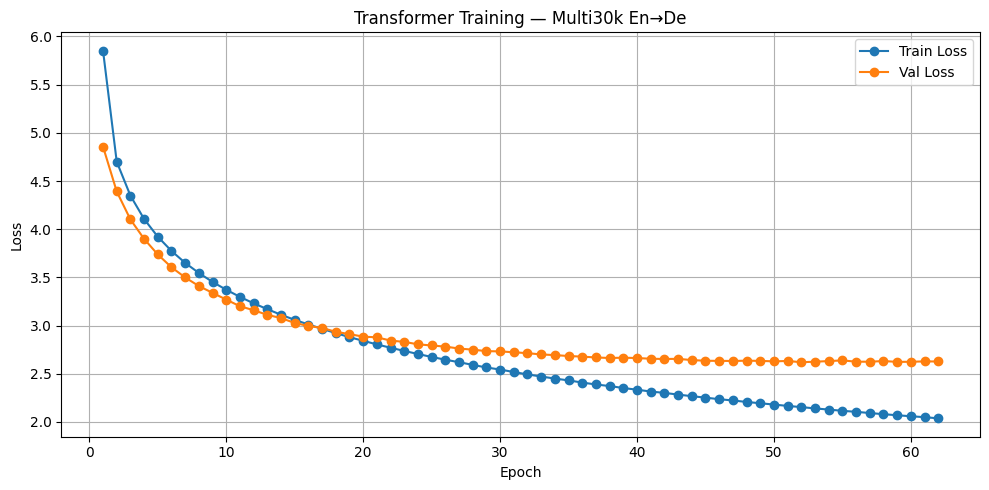

In [168]:
# plot after training
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses)+1),   val_losses,   label='Val Loss',   marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer Training — Multi30k En→De')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('D:\\Dummy\\Attention_is_all_you_need\\Trained Model\\loss_curve.png', dpi=150)
plt.show()

Inference

In [169]:
def translate(model, sentence, vocab_en, vocab_de, device, max_len=50):
    model.eval()

    # 1. tokenize and numericalize source
    tokens = [BOS_IDX] + [lookup(vocab_en, t) for t in tokenize_en(sentence)] + [EOS_IDX]
    src = torch.tensor(tokens).unsqueeze(0).to(device)  # (1, src_len)
    src_mask = make_src_mask(src, device)

    # 2. encode source once
    with torch.no_grad():
        src_emb = model.dropout(model.pe(model.src_emb(src)))
        enc_out = model.encoder(src_emb, src_mask)

    # 3. decode autoregressively — one token at a time
    tgt_tokens = [BOS_IDX]

    for _ in range(max_len):
        tgt = torch.tensor(tgt_tokens).unsqueeze(0).to(device)  # (1, current_len)
        tgt_mask = make_tgt_mask(tgt, device)

        with torch.no_grad():
            tgt_emb = model.dropout(model.pe(model.tgt_emb(tgt)))
            dec_out = model.decoder(tgt_emb, enc_out, src_mask, tgt_mask)
            logits  = model.proj(dec_out)  # (1, current_len, tgt_vocab_size)

        # take the last token's prediction
        next_token = logits[0, -1, :].argmax().item()
        tgt_tokens.append(next_token)

        # stop if <eos> predicted
        if next_token == EOS_IDX:
            break

    # 4. convert indices back to words
    idx_to_de = {v: k for k, v in vocab_de.items()}
    translated = [idx_to_de.get(i, '<unk>') for i in tgt_tokens[1:-1]]  # strip <bos> and <eos>
    return ' '.join(translated)

In [170]:
test_sentences = [
    "A man is playing guitar.",
    "Two dogs are running in the park.",
    "A woman is reading a book."
]

for sentence in test_sentences:
    translation = translate(model, sentence, vocab_en, vocab_de, device)
    print(f"EN: {sentence}")
    print(f"DE: {translation}")
    print()

EN: A man is playing guitar.
DE: ein mann spielt gitarre .

EN: Two dogs are running in the park.
DE: zwei hunde rennen im park .

EN: A woman is reading a book.
DE: eine frau liest ein buch .



Visualize Attention, Self-Attention and Cross-Attention

In [171]:
def get_attention(model, sentence, vocab_en, vocab_de, device):
    model.eval()

    # tokenize and encode source
    src_tokens = tokenize_en(sentence)
    src_ids    = [BOS_IDX] + [lookup(vocab_en, t) for t in src_tokens] + [EOS_IDX]
    src        = torch.tensor(src_ids).unsqueeze(0).to(device)
    src_mask   = make_src_mask(src, device)
    src_labels = ['<bos>'] + src_tokens + ['<eos>']

    # storage
    enc_attn  = {}   # encoder self-attention
    dec_attn  = {}   # decoder masked self-attention
    cross_attn = {}  # decoder cross-attention

    # hook function — captures attention weights
    def hook(storage, name):
        def fn(module, input, output):
            # recompute weights from input (q, k already projected + split)
            pass
        return fn

    # simpler approach: patch just the score computation
    original_forwards = {}

    def patch(mha, store):
        orig = mha.forward
        original_forwards[id(mha)] = orig

        def patched(x, context=None, mask=None):
            batch = x.size(0)
            kv = context if context is not None else x
            q = mha.split_heads(mha.wq(x),  batch)
            k = mha.split_heads(mha.wk(kv), batch)
            v = mha.split_heads(mha.wv(kv), batch)
            scores  = torch.matmul(q, k.transpose(-2,-1)) / (mha.d_k ** 0.5)
            if mask is not None:
                scores = scores.masked_fill(mask == 0, float('-inf'))
            weights = torch.softmax(scores, dim=-1)
            store[id(mha)] = weights.detach().cpu()   # save weights
            weights = mha.dropout(weights)
            out = torch.matmul(weights, v)
            out = out.transpose(1,2).contiguous().view(batch, -1, mha.n_heads * mha.d_k)
            return mha.wo(out)

        mha.forward = patched

    def unpatch(mha):
        mha.forward = original_forwards[id(mha)]

    # patch encoder layer 0 and decoder layer 0
    patch(model.encoder.layers[0].mha,  enc_attn)
    patch(model.decoder.layers[0].mha1, dec_attn)
    patch(model.decoder.layers[0].mha2, cross_attn)

    # greedy decode (fires all patched forwards)
    tgt_ids = [BOS_IDX]
    with torch.no_grad():
        src_emb = model.pe(model.src_emb(src))
        enc_out = model.encoder(src_emb, src_mask)
        for _ in range(50):
            tgt      = torch.tensor(tgt_ids).unsqueeze(0).to(device)
            tgt_mask = make_tgt_mask(tgt, device)
            tgt_emb  = model.pe(model.tgt_emb(tgt))
            dec_out  = model.decoder(tgt_emb, enc_out, src_mask, tgt_mask)
            next_tok = model.proj(dec_out)[0, -1, :].argmax().item()
            tgt_ids.append(next_tok)
            if next_tok == EOS_IDX:
                break

    # unpatch everything
    unpatch(model.encoder.layers[0].mha)
    unpatch(model.decoder.layers[0].mha1)
    unpatch(model.decoder.layers[0].mha2)

    idx_to_de  = {v: k for k, v in vocab_de.items()}
    tgt_labels = [idx_to_de.get(i, '<unk>') for i in tgt_ids]

    return (
        enc_attn[id(model.encoder.layers[0].mha)],
        dec_attn[id(model.decoder.layers[0].mha1)],
        cross_attn[id(model.decoder.layers[0].mha2)],
        src_labels,
        tgt_labels,
    )

In [172]:
def plot_attention(weights, x_labels, y_labels, title, cmap='Blues'):
    # weights: (batch, heads, q, k) — take head 0
    w = weights[0, 0].numpy()
    plt.figure(figsize=(8, 6))
    sns.heatmap(w, xticklabels=x_labels, yticklabels=y_labels,
                cmap=cmap, annot=True, fmt='.2f', vmin=0, vmax=1)
    plt.title(title)
    plt.xlabel('attending to →')
    plt.ylabel('query →')
    plt.tight_layout()
    plt.show()

In [173]:
sentence = "A man is playing guitar."

enc_w, dec_w, cross_w, src_labels, tgt_labels = get_attention(
    model, sentence, vocab_en, vocab_de, device
)

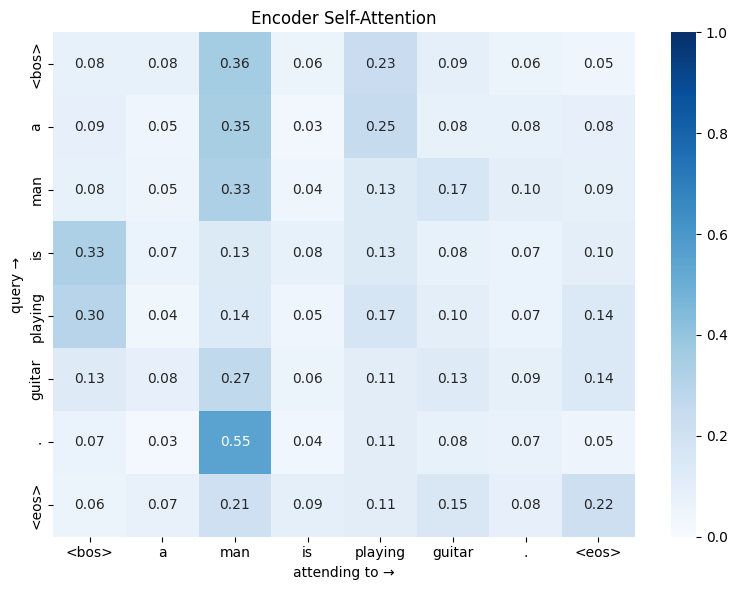

In [174]:
# encoder self-attention  (src → src)
plot_attention(enc_w,   src_labels, src_labels,  'Encoder Self-Attention',   cmap='Blues')

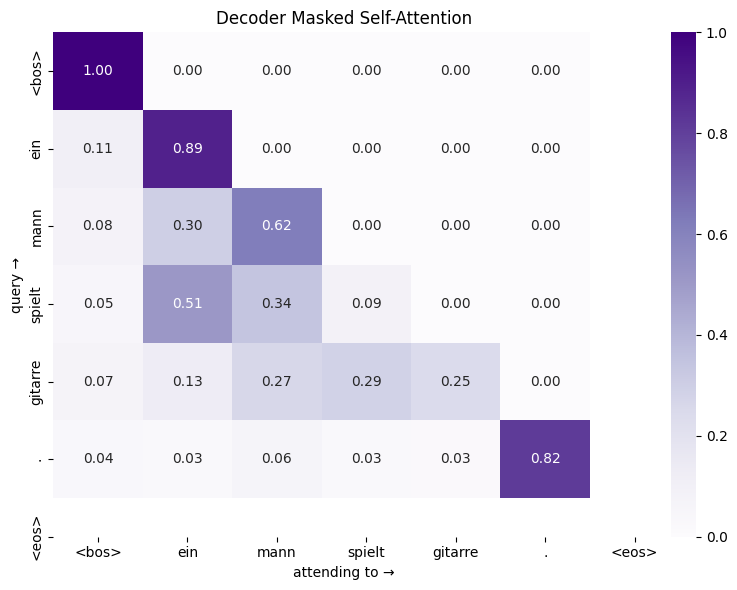

In [175]:
# decoder masked self-attention  (tgt → tgt, lower triangular)
plot_attention(dec_w,   tgt_labels, tgt_labels,  'Decoder Masked Self-Attention',  cmap='Purples')

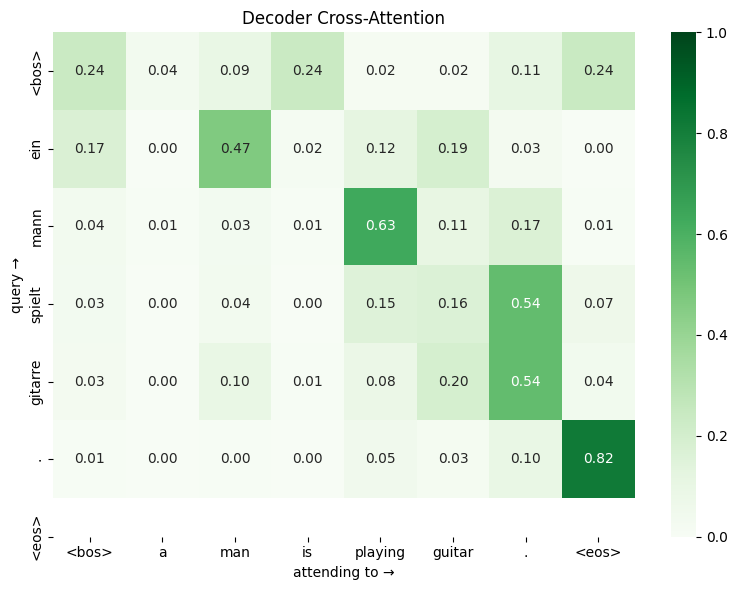

In [176]:
# cross-attention  (tgt queries → src keys)
plot_attention(cross_w, src_labels, tgt_labels,  'Decoder Cross-Attention',        cmap='Greens')